# Figures from "Pricing Adaptation"
This notebook recreates the python-generated figures used in "Pricing Adaptation: A Simulated Study of Poverty Intervention Strategies Under Climate Shocks" by V.M.Garibay & D. Roy (2025) and its Supplement.
The model and methods for generating output are described in the manuscript and the README file for [this repository](https://github.com/SDCCA/DGL-PTM/tree/experiments).
Due to storage constraints, it was necessary to process model output data remotely using `data_processor.py`, `scheme_data_processor.py`, and `disruption_data_processor.py`, the results of which were retrieved for visualization. Raw and processed outputs are available on [Zenodo](https://doi.org/10.5281/zenodo.17163314); the files necessary to run this notebook are in the `DataSummaries` folder in that zip file.

This notebook requires the Python packages `numpy`, `pandas`, `matplotlib`, and `scikit-learn`.


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator
from matplotlib.patches import Ellipse
import matplotlib.patheffects as path_effects
from matplotlib.lines import Line2D
from matplotlib.text import Text
from matplotlib.legend_handler import HandlerBase
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['font.size'] = 12


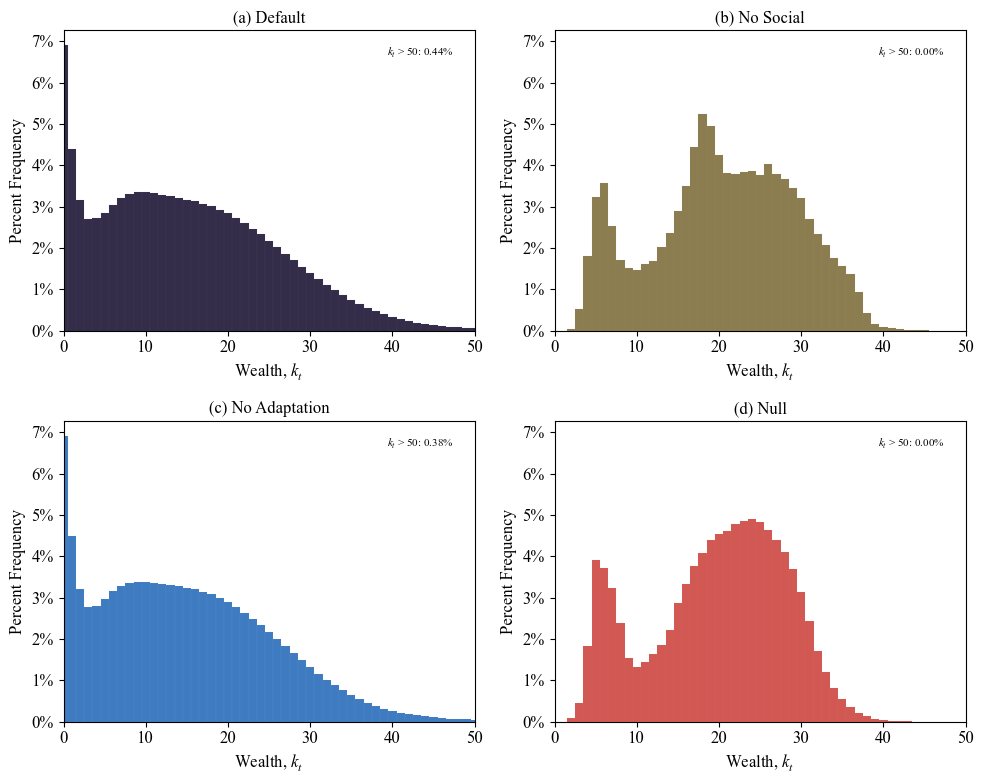

In [31]:
'''
Figure 1: Histogram representing the wealth distribution of agents at $t$=50
'''
data = pd.read_csv("./DataSummaries/wealth_histogram_data.csv")

def plot_histogram_data(df, label, title, ax, color, outline='white'):
    hist_data = df[df["label"] == label]
    ax.bar(hist_data["bin"], hist_data["frequency"], color=color, width=1.0,edgecolor=outline, linewidth=0.05)
    ax.set_title(title,fontsize=plt.rcParams['font.size'])
    ax.set_xlim(0, 50)
    ax.set_xlabel('Wealth, $k_t$')
    ax.set_ylabel('Percent Frequency')
    uncaptured = (hist_data['frequency'][hist_data['bin'] >= 50]).sum()
    ax.text(0.95, 0.95, f'$k_t$ > 50: {uncaptured:.2f}%', transform=ax.transAxes, fontsize=8, verticalalignment='top', horizontalalignment='right')

fig_hk, axs_hk = plt.subplots(2, 2, figsize=(10, 8))

# Plot histogram data for each scenario
plot_histogram_data(data, "default_arrangement", "(a) Default", axs_hk[0, 0], '#342d49','#70619e')
plot_histogram_data(data, "no_social_arrangement", "(b) No Social", axs_hk[0, 1], '#8b7d4f','#b6a87c')
plot_histogram_data(data, "no_adapt_arrangement", "(c) No Adaptation", axs_hk[1, 0], '#3f7bc1','#9fbde0')
plot_histogram_data(data, "null_arrangement", "(d) Null", axs_hk[1, 1], '#d15853','#e49d9a')

# Set matching y-axis limits for all subplots
max_ylim = max(ax.get_ylim()[1] for ax in axs_hk.flat)
for ax in axs_hk.flat:
    ax.set_ylim(0, max_ylim)
    y_ticks = ax.get_yticks()
    ax.yaxis.set_major_locator(FixedLocator(y_ticks))
    ax.set_yticklabels([f'{ y:.0f}%' for y in y_ticks])
plt.tight_layout()
plt.show()

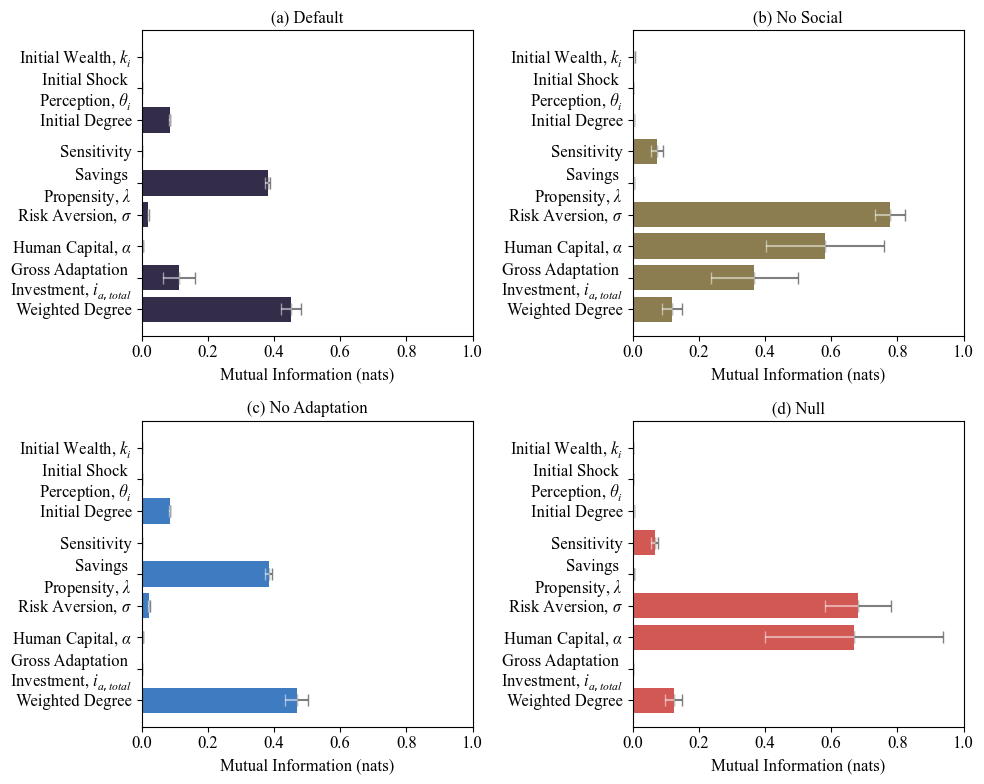

In [32]:
'''
Figure 2: Visual comparison of mutual information estimates for input variables on the wealth
'''
arrangements=['Default','No Social','No Adaptation','Null']
titles=['(a) Default','(b) No Social','(c) No Adaptation','(d) Null']
colors=['#342d49','#8b7d4f','#3f7bc1','#d15853']
edgecolors=['#70619e','#b6a87c','#9fbde0','#e49d9a']
mutual_info=pd.read_csv("./DataSummaries/mutual_info_updated.csv")
mutual_info.columns=['index', 'Arrangement','Seed','Variable','MI']
mutual_info_seeds=mutual_info[mutual_info['Seed']!="All"].groupby(['Arrangement','Variable']).agg(MI_mean=('MI','mean'),MI_sd=('MI','std')).reset_index()
mutual_info_all=mutual_info[mutual_info['Seed']=="All"]


original_order = ['weighted_degree','i_a_accumulated','alpha','sigma','lambda','sensitivity','degree_initial','theta_initial','wealth_initial']
mutual_info_seeds['Variable'] = pd.Categorical(mutual_info_seeds['Variable'], categories=original_order, ordered=True)
mutual_info_all['Variable'] = pd.Categorical(mutual_info_all['Variable'], categories=original_order, ordered=True)
mutual_info_seeds = mutual_info_seeds.sort_values('Variable').reset_index(drop=True)
mutual_info_all = mutual_info_all.sort_values('Variable').reset_index(drop=True)

fig_mi, axs_mi = plt.subplots(2, 2, figsize=(10, 8))
for i in range(4):
    subset=mutual_info_seeds[mutual_info_seeds['Arrangement']==arrangements[i]]
    axs_mi.flatten()[i].barh(subset['Variable'], subset['MI_mean'], color=colors[i])
    axs_mi.flatten()[i].errorbar(subset['MI_mean'], subset['Variable'], xerr=[np.zeros(len(subset)),subset['MI_sd']], fmt='none', ecolor='black', alpha=0.5, capsize=4)
    axs_mi.flatten()[i].errorbar(subset['MI_mean'], subset['Variable'], xerr=[subset['MI_sd'],np.zeros(len(subset))], fmt='none', ecolor='white', alpha=0.5, capsize=4)
    
    axs_mi.flatten()[i].set_title(titles[i],fontsize=plt.rcParams['font.size'])
    axs_mi.flatten()[i].set_xlabel('Mutual Information (nats)')
    axs_mi.flatten()[i].set_xlim(0, 1)
    axs_mi.flatten()[i].set_yticklabels(['Weighted Degree', 'Gross Adaptation \nInvestment, $i_{a,total}$', 'Human Capital, $\\alpha$', 'Risk Aversion, $\\sigma$', 'Savings \nPropensity, $\\lambda$', 'Sensitivity', 'Initial Degree', 'Initial Shock \nPerception, $\\theta_i$', 'Initial Wealth, $k_i$'],wrap=False)

plt.tight_layout()
plt.show()

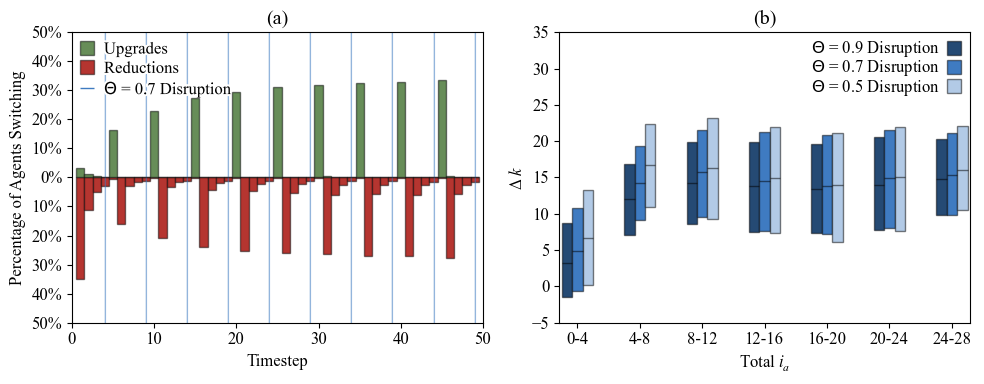

In [33]:
'''
Figure 3: Under sheduled exposure to shocks, (a) the percentage of agents changing their investment in adaptation and 
(b) a comparison of change in wealth from initialization to $t$=50 versus the total investment in adaptation
'''
switches_df = pd.read_csv('./DataSummaries/disrupt_7_switches.csv')
comparison_data = pd.read_csv('./DataSummaries/disruption_comparison_boxplot_bin_size_4.csv')

fig, axs = plt.subplots( 1,2, figsize=(10, 4))


#Bar chart of upgrades and reductions by time step
for timestep in np.arange(4, switches_df["time_step"].max() + 1, 5):
        axs[0].axvline(timestep, color='#3f7bc1', alpha=1, linestyle='-', linewidth=0.2)
        axs[0].axvline(timestep, color='#3f7bc1', alpha=0.5, linestyle='-', linewidth=0.5)
        axs[0].axvline(timestep, color='#3f7bc1', alpha=0.2, linestyle='-', linewidth=1)

axs[0].bar(switches_df["time_step"], switches_df["upgrades"]*100, color='#678d58', edgecolor=(0,0,0,0.5), width=1,label='Upgrades',zorder=10)#,align='edge')
axs[0].bar(switches_df["time_step"], -switches_df["reductions"]*100, color='#b53530', edgecolor=(0,0,0,0.5), width=1,label='Reductions')#,align='edge')
axs[0].set_xlabel("Timestep")
axs[0].set_ylabel("Percentage of Agents Switching")
axs[0].set_title("(a)")

legend_handles = [
    Line2D([0], [0], color='#678d58', marker='s', markersize=10, linestyle='None', markeredgecolor=(0, 0, 0, 0.5), label='Upgrades'),
    Line2D([0], [0], color='#b53530', marker='s', markersize=10, linestyle='None', markeredgecolor=(0, 0, 0, 0.5), label='Reductions'),
    Line2D([0], [0], color='#3f7bc1', alpha=1, marker='_', markersize=10, linestyle='None', label='$\\Theta$ = 0.7 Disruption')]
legend=axs[0].legend(handles=legend_handles,loc='upper left', frameon=False,labelspacing=0.2, handletextpad= 0,bbox_to_anchor=(-0.04, 1.02))

for text in legend.get_texts():
    text.set_path_effects([
        path_effects.Stroke(linewidth=3, foreground='white'),
        path_effects.Normal() 
    ])
axs[0].set_yticks([-50,-40,-30, -20, -10, 0, 10, 20, 30,40,50])
axs[0].set_yticklabels(["50%","40%","30%", "20%", "10%", '0%', "10%", "20%", "30%","40%","50%"])
axs[0].set_xlim(0, 50)
axs[0].set_xlim(0, 50)
axs[0].set_ylim(-50, 50)


class HandlerRightLabel(HandlerBase):
    def __init__(self, label_map):
        super().__init__()
        self.label_map = label_map  # Store label mapping

    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        label = self.label_map.get(orig_handle, '')  # Retrieve the correct label

        # Create text label first
        text = Text(width - 103, height / 2 - 1, label, verticalalignment='center', 
                    horizontalalignment='left', transform=trans)

        # Create marker manually
        handle = Line2D([width], [height / 2], color=orig_handle.get_color(), 
                        marker=orig_handle.get_marker(), markersize=orig_handle.get_markersize(), 
                        linestyle='None', markeredgecolor=orig_handle.get_markeredgecolor(), 
                        transform=trans)

        return [text, handle] 

bin_size = 4

# Group data by bins and labels
bins = comparison_data['bin_start'].unique()
bins.sort()
labels = comparison_data['label'].unique()
binned_data = {label: [] for label in labels}
for label in labels:
    for bin_start in bins:
        bin_data = comparison_data[(comparison_data['bin_start'] == bin_start) & (comparison_data['label'] == label)]
        binned_data[label].append(bin_data[['min', 'q1', 'median', 'q3', 'max']].values.flatten())
# Create boxplot
positions = {label: bins[:] + bin_size / 2 + (i - 1) * bin_size / 6 for i, label in enumerate(labels)}
colors = ['#254a74', '#3f7bc1', '#b2cae6']
legend_labels = ["$\\Theta$ = 0.9 Disruption", "$\\Theta$ = 0.7 Disruption", "$\\Theta$ = 0.5 Disruption"]


for i, label in enumerate(labels):
    for j, bin_data in enumerate(binned_data[label][:len(positions[label])]):
        axs[1].bxp([{
            'med': bin_data[2],
            'q1': bin_data[1],
            'q3': bin_data[3],
            'whislo': bin_data[0],
            'whishi': bin_data[4]
       # }], positions=[positions[label][j]], widths=bin_size / 6, showfliers=False, patch_artist=True, boxprops=dict(facecolor=colors[i],edgecolor=(0,0,0,0.5)), medianprops=dict(color="black", alpha=0.5),whiskerprops=dict(color="black", alpha=0.5))
        }], positions=[positions[label][j]], widths=bin_size / 6, showfliers=False, patch_artist=True, boxprops=dict(facecolor=colors[i],edgecolor=(0,0,0,0.5)), medianprops=dict(color="black", alpha=0.5),whiskerprops=dict(color="none"))

axs[1].set_xlabel("Total $i_a$")
axs[1].set_ylabel("Δ $k$")
axs[1].set_title("(b)")
axs[1].set_ylim(-5, 35)
axs[1].set_xticks(bins + bin_size / 2)
axs[1].set_xticklabels([f'{int(bins[i])}-{int(bins[i]) + bin_size}' for i in range(len(bins))])
legend_handles = [Line2D([0], [0], color=color, marker='s', markersize=10, linestyle='None', markeredgecolor=(0,0,0,0.5), label="") for color, label in zip(colors, labels)]
axs[1].legend(handles=legend_handles, loc='upper right', frameon=False, handler_map={Line2D: HandlerRightLabel({handle: label for handle, label in zip(legend_handles, legend_labels)})}, handlelength= 0,labelspacing=0.2,bbox_to_anchor=(1.03, 1.02))#, handletextpad=0, labelspacing=0)
plt.tight_layout()
plt.savefig('switches_delta_k_vs_i_a_comparison.pdf')
plt.show()


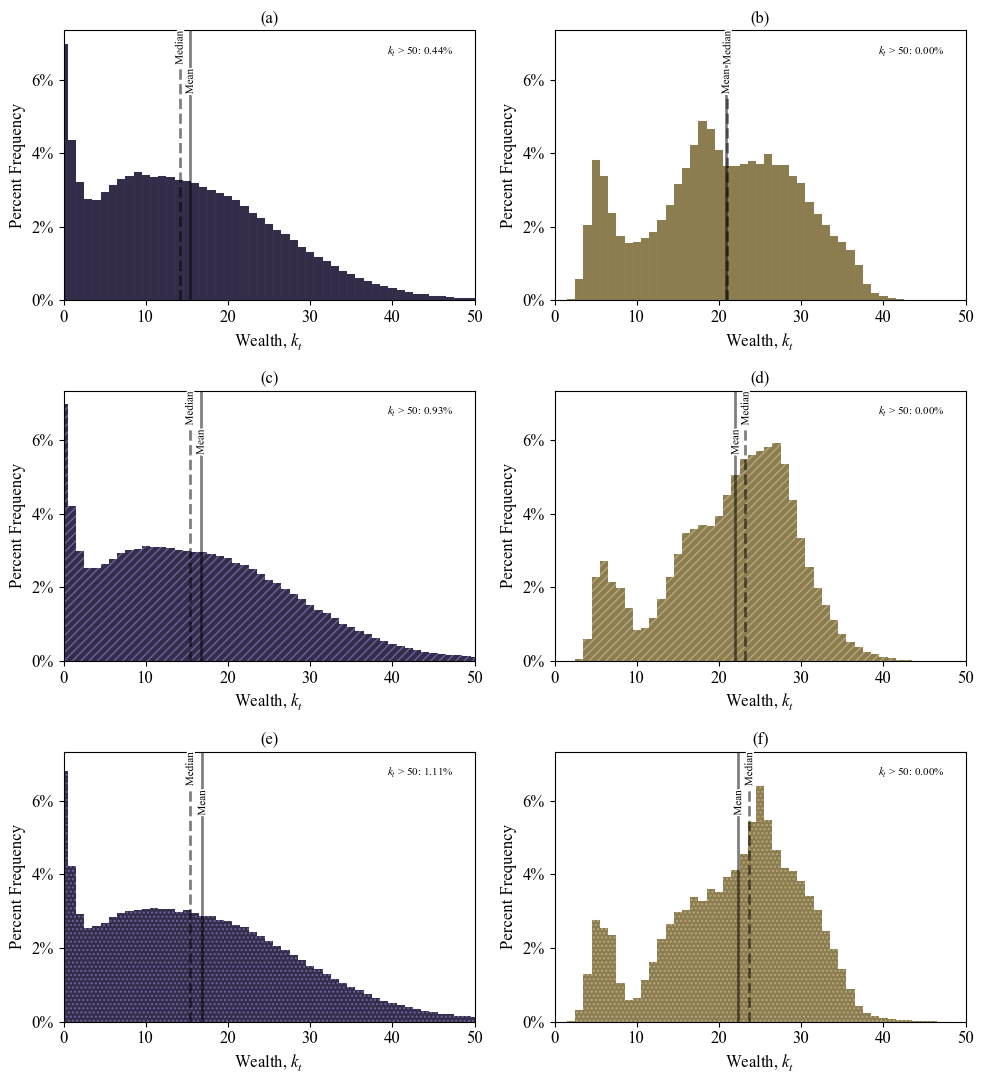

In [34]:

'''
Figure 4: Histograms of financial capital for studied intervention schemes
'''
data = pd.read_csv("./DataSummaries/scheme_wealth_histogram_data_t50.csv")
summary = pd.read_csv("./DataSummaries/scheme_wealth_histogram_data_t50_summary.csv")
fig_hkv, axs_hkv = plt.subplots(3, 2, figsize=(10, 11))

def plot_histogram_data(df, label, title, ax, color, outline='white', hatch='',summary=None):
    hist_data = df[df["Arrangement"] == "_".join(label.split("_")[1:])]
    hist_data = hist_data[hist_data["Scheme"] == label.split("_")[0]]
    summary_data = summary[summary["Arrangement"] == "_".join(label.split("_")[1:])]
    summary_data = summary_data[summary_data["Scheme"] == label.split("_")[0]]
    ax.bar(hist_data["bin"], hist_data["frequency"], color=color, width=1.0,edgecolor=outline, linewidth=0.04,hatch=hatch)
    ax.axvline(summary_data["Mean"].values[0], color='black', alpha=0.5,linestyle='-', linewidth=2, label='Mean')
    ax.axvline(summary_data["Median"].values[0], color='black', alpha=0.5,linestyle='--', linewidth=2, label='Median')
    mean_text=ax.text(summary_data["Mean"].values[0], 5.6, 'Mean', color='black', ha='center', va='bottom', rotation=90, fontsize=8)
    mean_text.set_path_effects([path_effects.withStroke(linewidth=2.5, foreground='white')])
    median_text=ax.text(summary_data["Median"].values[0], 6.4, 'Median', color='black', ha='center', va='bottom', rotation=90, fontsize=8)
    median_text.set_path_effects([path_effects.withStroke(linewidth=2.5, foreground='white')])
    ax.set_title(title,fontsize=plt.rcParams['font.size'])
    ax.set_xlim(0, 50)
    ax.set_xlabel('Wealth, $k_t$')
    ax.set_ylabel('Percent Frequency')
    uncaptured = (hist_data['frequency'][hist_data['bin'] >= 50]).sum()
    ax.text(0.95, 0.95, f'$k_t$ > 50: {uncaptured:.2f}%', transform=ax.transAxes, fontsize=8, verticalalignment='top', horizontalalignment='right')

# Plot histogram data for each scenario
plot_histogram_data(data, "SchemeSQ_default", "(a)", axs_hkv[0, 0], '#342d49','#70619e',summary=summary)
plot_histogram_data(data, "SchemeSQ_no_social", "(b)", axs_hkv[0, 1], '#8b7d4f','#b6a87c',summary=summary)
plot_histogram_data(data, "SchemeA_default", "(c)", axs_hkv[1, 0], '#342d49','#70619e','////',summary=summary)
plot_histogram_data(data, "SchemeA_no_social", "(d)", axs_hkv[1, 1], '#8b7d4f','#b6a87c','////',summary=summary)
plot_histogram_data(data, "SchemeB_default", "(e)", axs_hkv[2, 0], '#342d49','#70619e','....',summary=summary)
plot_histogram_data(data, "SchemeB_no_social", "(f)", axs_hkv[2, 1], '#8b7d4f','#b6a87c','....',summary=summary)

# Set matching y-axis limits for all subplots
max_ylim = max(ax.get_ylim()[1] for ax in axs_hkv.flat)
for ax in axs_hkv.flat:
    ax.set_ylim(0, max_ylim)
    y_ticks = ax.get_yticks()
    ax.yaxis.set_major_locator(FixedLocator(y_ticks))
    ax.set_yticklabels([f'{ y:.0f}%' for y in y_ticks])

plt.tight_layout()
plt.show()

y = 0.5231 * x^0.6000


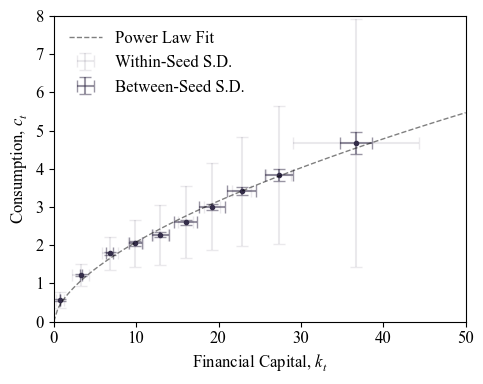

In [35]:
'''
Supplementary Item 1: Plot of consumption against wealth at $t$=50
'''

percentile_data=pd.read_csv("./DataSummaries/percentile_wealth_consumption.csv")
def within_seed_sd(series):
    #square root of mean variance is mean sd
    return np.sqrt(np.mean(series ** 2))

def power_law(x, a, b):
    return a * np.power(x, b)

percentile_plot_data = percentile_data.groupby(['model','wealth_percentile']).agg(wealth=('mean_wealth', 'mean'),
    consumption=('mean_consumption', 'mean'),inter_seed_sd_wealth=('mean_wealth','std'), 
    intra_seed_sd_wealth=('sd_wealth',within_seed_sd),inter_seed_sd_consumption=('mean_consumption','std'), 
    intra_seed_sd_consumption=('sd_consumption',within_seed_sd)).reset_index()
arrangements=['default_arrangement','no_social_arrangement','no_adapt_arrangement','null_arrangement']
colors=['#342d49','#8b7d4f','#3f7bc1','#d15853']

#with error bars, Default only
fig_pkcebd, axs_pkcebd = plt.subplots(figsize=(5, 4))

for i in range(1):
    plot_df = percentile_plot_data[percentile_plot_data['model'] == arrangements[i]].set_index('wealth_percentile')
    
    axs_pkcebd.errorbar(plot_df['wealth'], plot_df['consumption'],
                             xerr=plot_df['intra_seed_sd_wealth'], yerr=plot_df['intra_seed_sd_consumption'],
                             fmt='none', color=colors[i], alpha=0.1, capsize=4,label='Within-Seed S.D.')
    axs_pkcebd.errorbar(plot_df['wealth'], plot_df['consumption'],
                             xerr=plot_df['inter_seed_sd_wealth'], yerr=plot_df['inter_seed_sd_consumption'],
                             fmt='none', color=colors[i], alpha=0.5, capsize=4,label='Between-Seed S.D.')
    
    axs_pkcebd.scatter(plot_df['wealth'], plot_df['consumption'], color=colors[i], marker='.')
    axs_pkcebd.set_xlabel('Financial Capital, $k_t$')
    axs_pkcebd.set_ylabel('Consumption, $c_t$')
    axs_pkcebd.set_xlim(0, 50)
    axs_pkcebd.set_ylim(0, 8)

    popt, pcov = curve_fit(power_law, plot_df['wealth'], plot_df['consumption'])
    x_fit = np.linspace(0, 50, 100)
    y_fit = power_law(x_fit, *popt)
    axs_pkcebd.plot(x_fit, y_fit, color='black', alpha=0.5,linestyle='--', linewidth=1, label='Power Law Fit')  
    axs_pkcebd.legend(loc='upper left',frameon=False)

    # Display the equation on the plot
    print(f'y = {popt[0]:.4f} * x^{popt[1]:.4f}')
    #axs_pkcebd.text(0.05, 0.9, equation_text, transform=axs_pkcebd.transAxes, fontsize=10, verticalalignment='top', color='red')


plt.tight_layout()
plt.show()

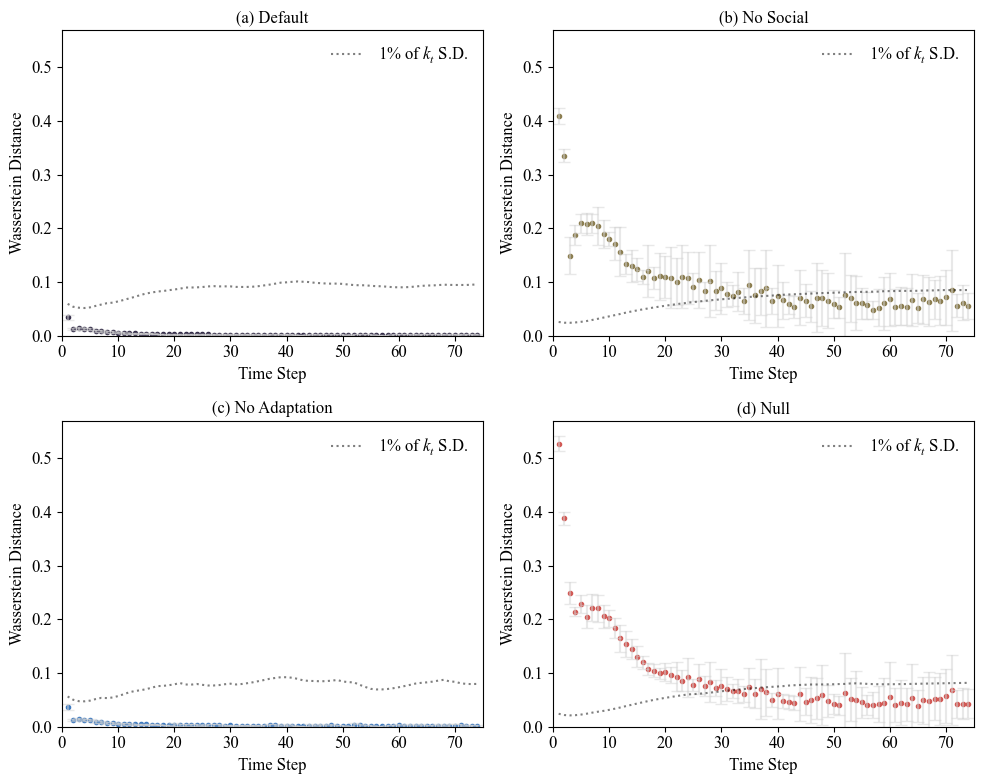

In [36]:

'''
Supplementary Item 3: Mean and standard deviation of Wasserstein distances computed for the $k_t$ histograms 
'''
data = pd.read_csv("./DataSummaries/Wasserstein_distances.csv")
data = data.groupby(['Arrangement', 't_1']).agg(WD_mean=('Wasserstein_distance', 'mean'), WD_sd=('Wasserstein_distance', 'std'), k_sd=('k_t_1_sdev','min')).reset_index()

def plot_WD_data(df, label, title, ax, color):
    point_data = df[df["Arrangement"] == label]
    ax.scatter(point_data["t_1"], point_data["WD_mean"], color=color,marker='.')
    ax.errorbar(point_data["t_1"], point_data["WD_mean"], yerr=point_data["WD_sd"], fmt='none', ecolor='lightgrey', alpha=0.5, capsize=4)
    ax.plot(point_data["t_1"], (point_data["k_sd"]*0.01), color='black', alpha=0.5, linestyle=':',label='1% of $k_t$ S.D.')
    ax.set_title(title,fontsize=plt.rcParams['font.size'])
    ax.set_xlim(0, 75)
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Wasserstein Distance')
    ax.legend(frameon=False)

fig_wdk, axs_wdk = plt.subplots(2, 2, figsize=(10, 8))

# Plot wasserstien distance data for each scenario
plot_WD_data(data, "default_arrangement", "(a) Default", axs_wdk[0, 0], '#342d49')
plot_WD_data(data, "no_social_arrangement", "(b) No Social", axs_wdk[0, 1], '#8b7d4f')
plot_WD_data(data, "no_adapt_arrangement", "(c) No Adaptation", axs_wdk[1, 0], '#3f7bc1')
plot_WD_data(data, "null_arrangement", "(d) Null", axs_wdk[1, 1], '#d15853')


# Set matching y-axis limits for all subplots
max_ylim = max(ax.get_ylim()[1] for ax in axs_wdk.flat)
for ax in axs_wdk.flat:
    ax.set_ylim(0, max_ylim)

plt.tight_layout()
plt.show()

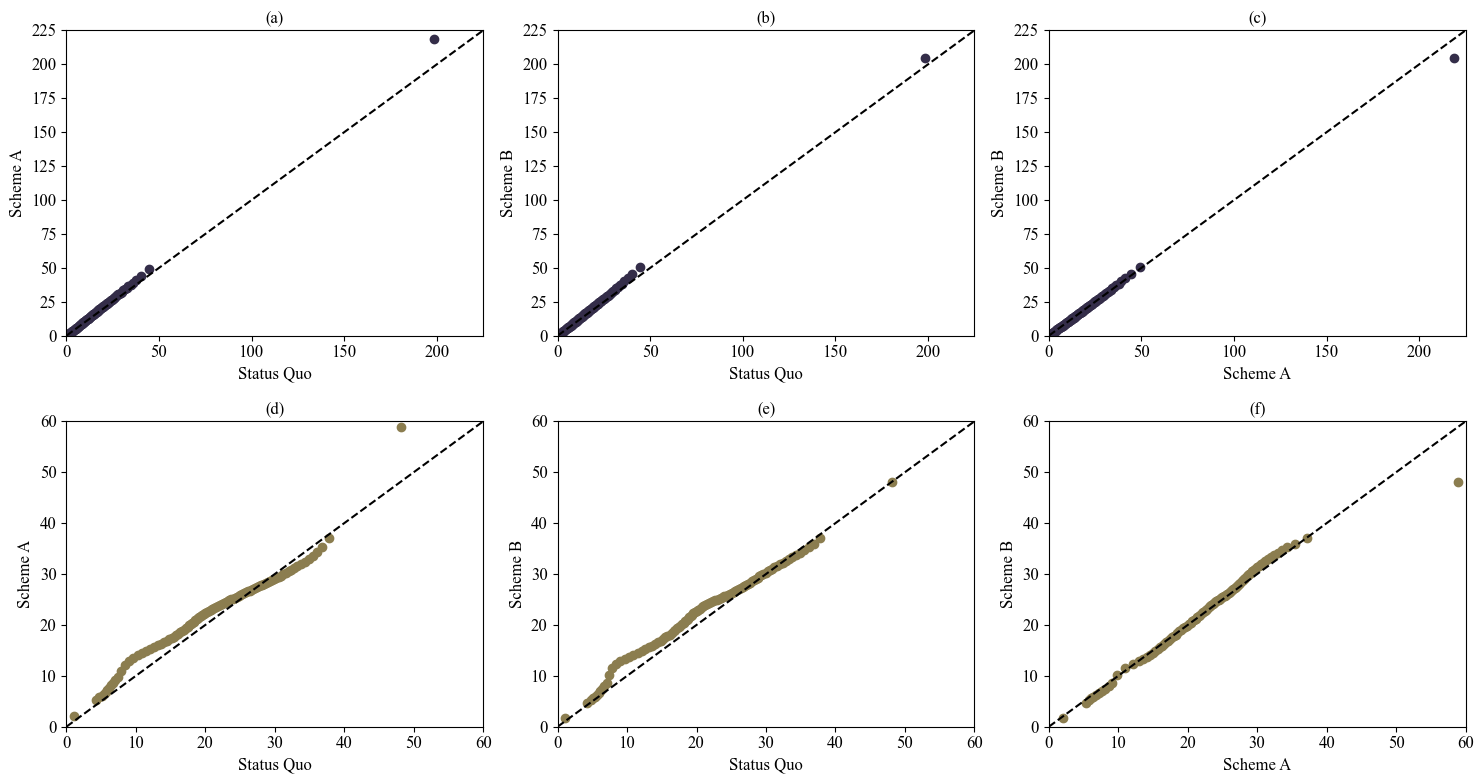

In [37]:
'''
Supplementary Item 4: Quantile-quantile plots for the wealth distributions at $t$=50
'''
quantiledf = pd.read_csv("./DataSummaries/scheme_wealth_quantile_data_t50.csv")

def plot_QQ_data(df, pair, titles, ax, color, lims, exclusion = None):
    q_x = df[df["Arrangement"] == "_".join(pair[0].split("_")[1:])]
    q_x = q_x[q_x["Scheme"] == pair[0].split("_")[0]]
    q_y = df[df["Arrangement"] == "_".join(pair[1].split("_")[1:])]
    q_y = q_y[q_y["Scheme"] == pair[1].split("_")[0]]

    ax.plot(lims,lims, color='black', linestyle='--')
    ax.scatter(q_x["Value"], q_y["Value"], color=color)
    ax.set_xlabel(titles[0])
    ax.set_ylabel(titles[1])
    ax.set_title(titles[2],fontsize=plt.rcParams['font.size'])
    ax.set_xlim(lims)
    ax.set_ylim(lims)

fig_qq,axs_qq = plt.subplots(2, 3, figsize=(15, 8))

# Plot Quantile data for each pair
plot_QQ_data(quantiledf, ["SchemeSQ_default","SchemeA_default"], ["Status Quo","Scheme A","(a)"], axs_qq[0, 0], '#342d49', [0, 225], exclusion=[50,175])
plot_QQ_data(quantiledf, ["SchemeSQ_default","SchemeB_default"], ["Status Quo","Scheme B","(b)"], axs_qq[0, 1], '#342d49', [0, 225])
plot_QQ_data(quantiledf, ["SchemeA_default","SchemeB_default"], ["Scheme A","Scheme B","(c)"], axs_qq[0, 2], '#342d49', [0, 225])
plot_QQ_data(quantiledf, ["SchemeSQ_no_social","SchemeA_no_social"], ["Status Quo","Scheme A","(d)"], axs_qq[1, 0], '#8b7d4f', [0, 60])
plot_QQ_data(quantiledf, ["SchemeSQ_no_social","SchemeB_no_social"], ["Status Quo","Scheme B","(e)"], axs_qq[1, 1], '#8b7d4f', [0, 60])
plot_QQ_data(quantiledf, ["SchemeA_no_social","SchemeB_no_social"], ["Scheme A","Scheme B","(f)"], axs_qq[1, 2], '#8b7d4f', [0, 60])

plt.tight_layout()
plt.show()